# 01 - Introduction to VAR: Complete Solution

This is the **complete solution** for the VAR introduction notebook.
All exercises are fully resolved with outputs saved.

---

## Topics covered

1. VAR(p) model theory and estimation
2. Lag order selection (AIC, BIC, HQIC, FPE)
3. Fitting VAR models with `chronobox`
4. Coefficient interpretation
5. Stability analysis
6. Model diagnostics and forecasting
7. **Exercise 1: VAR on US Macro data** (SOLVED)
8. **Exercise 2: Model comparison across lag orders** (SOLVED)

---

### The VAR(p) model

$$Y_t = A_1 Y_{t-1} + A_2 Y_{t-2} + \cdots + A_p Y_{t-p} + c + u_t$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
import os

from chronobox import VAR
from chronobox.selection.lag_selection import select_lag_order

sys.path.insert(0, os.path.join("..", "utils"))
from plot_helpers import plot_multivariate_series

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
np.set_printoptions(precision=4, suppress=True)

print("All imports loaded successfully.")

All imports loaded successfully.


## 1. Loading the Canadian macroeconomic dataset

| Variable | Description |
|----------|-------------|
| `e`      | Employment rate |
| `prod`   | Labour productivity |
| `rw`     | Real wage |
| `U`      | Unemployment rate |

In [2]:
data_path = os.path.join("..", "data", "canada_macro.csv")
df = pd.read_csv(data_path)
print(f"Shape: {df.shape}")
print(f"Period: {df['date'].iloc[0]} to {df['date'].iloc[-1]}")
df.head()

Shape: (84, 5)
Period: 1980-01-01 to 2000-10-01


,date,e,prod,rw,U
0,1980-01-01,922.0427,417.8606,1.9044,4.0
1,1980-04-01,919.8995,419.0815,2.2816,4.0
2,1980-07-01,918.8644,421.0036,2.5554,4.0
3,1980-10-01,913.0655,422.2095,2.3960,4.0
4,1981-01-01,914.3792,421.7100,2.8166,4.0


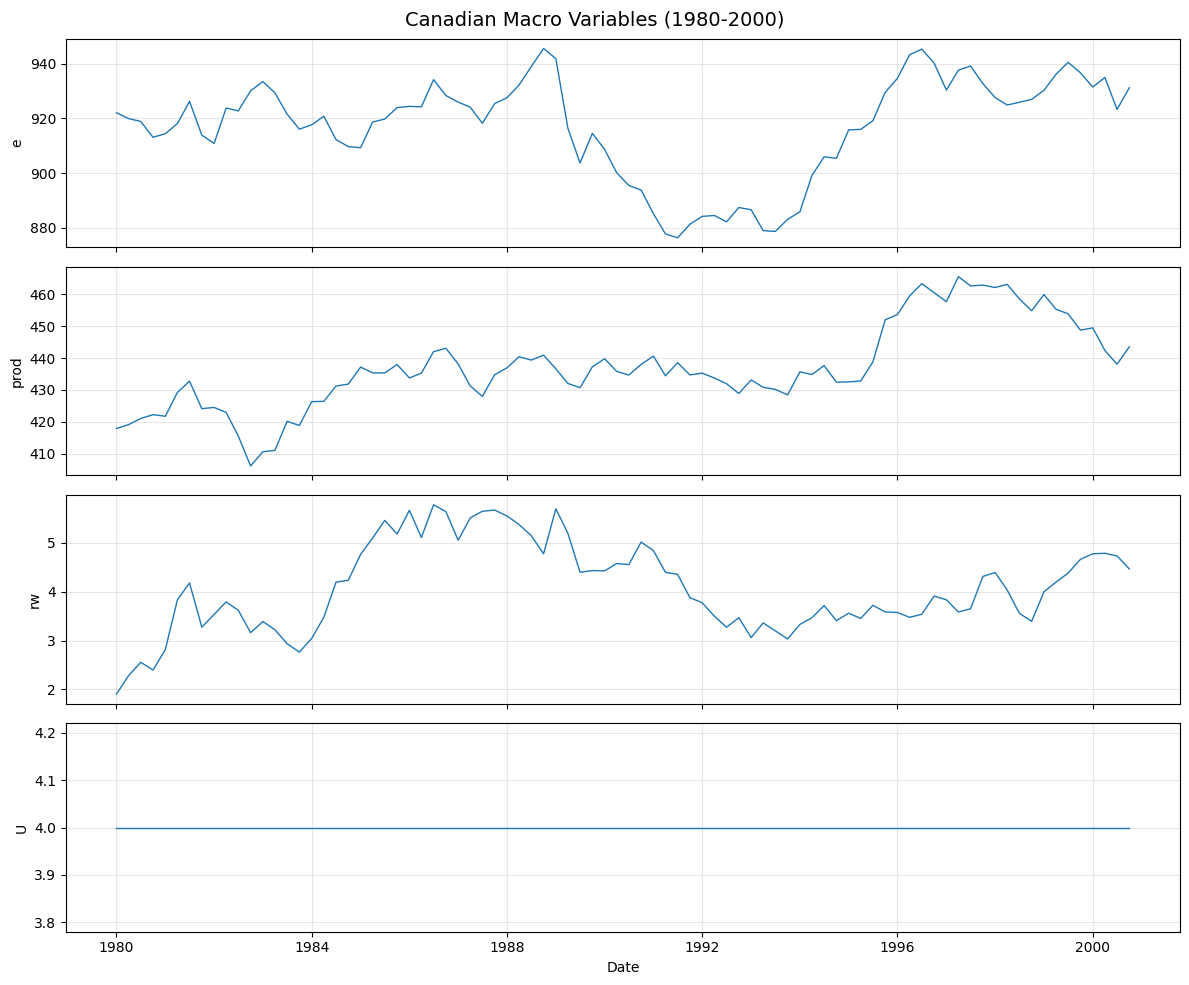

In [3]:
fig = plot_multivariate_series(df, date_col="date", title="Canadian Macro Variables (1980-2000)")
plt.show()

## 2. Lag order selection

In [4]:
endog = df[["e", "prod", "rw", "U"]].values
var_names = ["e", "prod", "rw", "U"]

lag_results = select_lag_order(endog, maxlags=8, trend="c")
print(lag_results.summary())

VAR Lag Order Selection
 Lag           AIC           BIC          HQIC             FPE
------------------------------------------------------------------------
   0     -58.7743     -58.7743     -58.7743   3.281141e-26 
   1     -61.0146     -60.5483     -60.8272   3.498042e-27 
   2     -62.9240     -61.9848     -62.5470   5.204098e-28 
   3     -64.2942*    -62.8752*    -63.7249*  1.334012e-28*
   4     -64.2358     -62.3302     -63.4718   1.437448e-28 
   5     -63.1227     -60.7232     -62.1614   4.496569e-28 
   6     -62.1780     -59.2775     -61.0169   1.206801e-27 
   7     -60.4996     -57.0905     -59.1360   6.889759e-27 
   8     -61.9747     -58.0492     -60.4059   1.728593e-27 
------------------------------------------------------------------------
* indicates lag order selected by the criterion

    AIC selects lag order 3
    BIC selects lag order 3
    FPE selects lag order 3
   HQIC selects lag order 3


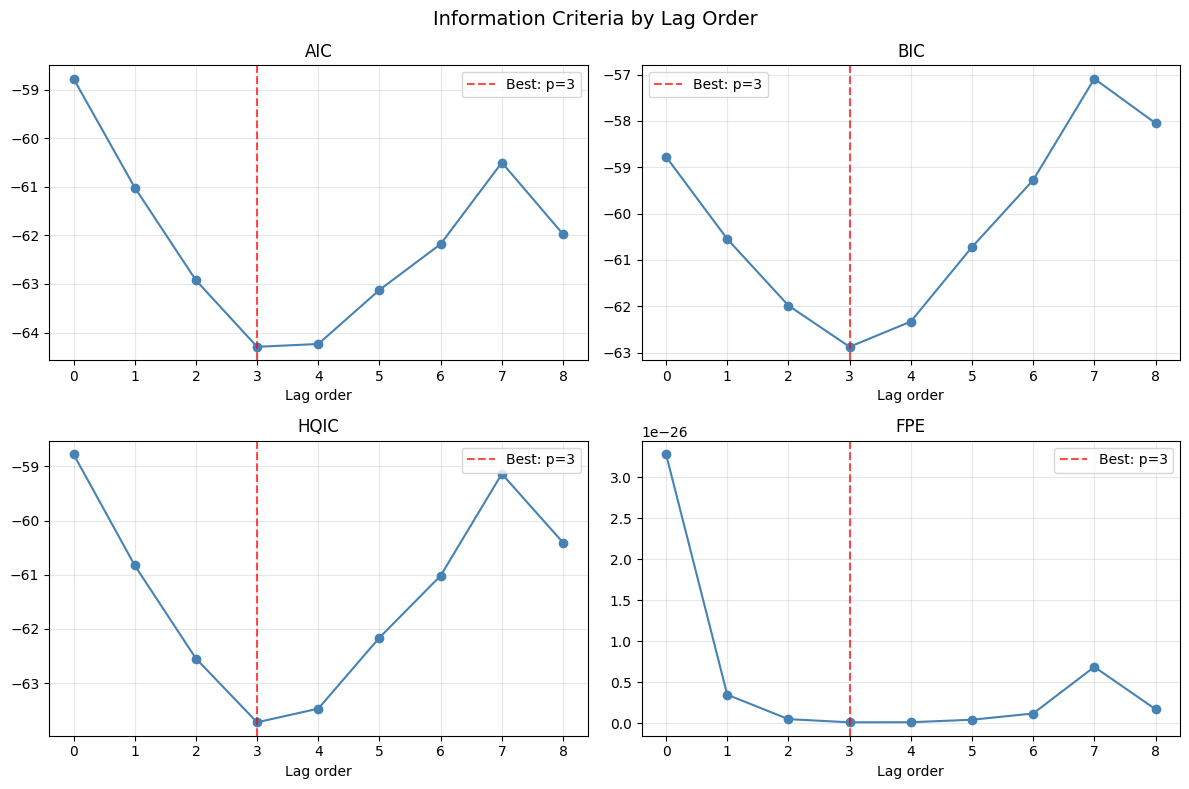


Selected lag orders:
  aic: p = 3
  bic: p = 3
  hqic: p = 3
  fpe: p = 3


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Information Criteria by Lag Order", fontsize=14)

criteria = {"AIC": lag_results.aic, "BIC": lag_results.bic,
            "HQIC": lag_results.hqic, "FPE": lag_results.fpe}

for ax, (name, vals) in zip(axes.flat, criteria.items()):
    lags = sorted(vals.keys())
    values = [vals[l] for l in lags]
    ax.plot(lags, values, "o-", color="steelblue")
    best = min(vals, key=vals.get)
    ax.axvline(best, color="red", linestyle="--", alpha=0.7, label=f"Best: p={best}")
    ax.set_title(name)
    ax.set_xlabel("Lag order")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSelected lag orders:")
for crit, order in lag_results.selected_orders.items():
    print(f"  {crit}: p = {order}")

## 3. Fitting the VAR model

In [6]:
model = VAR(lags=2, trend="c")
results = model.fit(endog, names=var_names)

try:
    print(results.summary())
except np.linalg.LinAlgError:
    print(f"VAR({results.k_ar}) estimated successfully.")
    print(f"Equations: {results.neqs}, Obs: {results.nobs}")
    print(f"AIC: {results.aic:.4f}, BIC: {results.bic:.4f}")

  VAR(2) Estimation Results
  No. of equations:   4
  No. of lags:        2
  No. of obs (total): 84
  No. of obs (used):  82
  Trend:              c
  Stable:             True
  AIC:                -62.9240
  BIC:                -61.9848
  HQIC:               -62.5470
  FPE:                5.204098e-28

------------------------------------------------------------------------------
  Equation: e
------------------------------------------------------------------------------
  Variable                     Coef      Std.Err     t-stat    p-value
  --------------------------------------------------------------------------
  L1.e                     1.141158     0.120367     9.4807     0.0000
  L1.prod                  0.185731     0.182451     1.0180     0.3121
  L1.rw                   -4.513551     2.185617    -2.0651     0.0425
  L1.U                     6.289508     4.805223     1.3089     0.1947
  L2.e                    -0.201736     0.119598    -1.6868     0.0959
  L2.prod          

In [7]:
print("Coefficient matrix A_1 (lag 1):")
A1 = pd.DataFrame(results.coefs[0], index=var_names, columns=var_names)
print(A1.round(4))

print("\nCoefficient matrix A_2 (lag 2):")
A2 = pd.DataFrame(results.coefs[1], index=var_names, columns=var_names)
print(A2.round(4))

print(f"\nIntercept: {results.intercept.round(4)}")

print(f"\nResidual covariance matrix:")
print(pd.DataFrame(results.sigma_u, index=var_names, columns=var_names).round(6))

Coefficient matrix A_1 (lag 1):
           e    prod      rw       U
e     1.1412  0.1857 -4.5136  6.2895
prod -0.0308  0.9968 -0.8504  2.4206
rw    0.0102 -0.0034  0.8504 -0.2253
U    -0.0000 -0.0000 -0.0000  0.4848

Coefficient matrix A_2 (lag 2):
           e    prod      rw       U
e    -0.2017 -0.1717  3.9634  6.2895
prod  0.0418 -0.0583  0.1593  2.4206
rw   -0.0076  0.0033  0.0284 -0.2253
U     0.0000  0.0000 -0.0000  0.4848

Intercept: [ 1.5724  0.6052 -0.0563  0.1212]

Residual covariance matrix:
              e       prod        rw    U
e     43.492327  10.309262  0.425843 -0.0
prod  10.309262  20.732885  0.373050 -0.0
rw     0.425843   0.373050  0.132747  0.0
U     -0.000000  -0.000000  0.000000  0.0


## 4. Stability analysis

Is the VAR stable? True

Eigenvalues of the companion matrix:
  lambda_1 = 0.9797+0.0000j  (modulus = 0.9797)
  lambda_2 = 0.9321+0.0000j  (modulus = 0.9321)
  lambda_3 = 0.9003+0.0121j  (modulus = 0.9004)
  lambda_4 = 0.9003-0.0121j  (modulus = 0.9004)
  lambda_5 = -0.4949+0.0000j  (modulus = 0.4949)
  lambda_6 = 0.1228+0.1762j  (modulus = 0.2148)
  lambda_7 = 0.1228-0.1762j  (modulus = 0.2148)
  lambda_8 = 0.0100+0.0000j  (modulus = 0.0100)


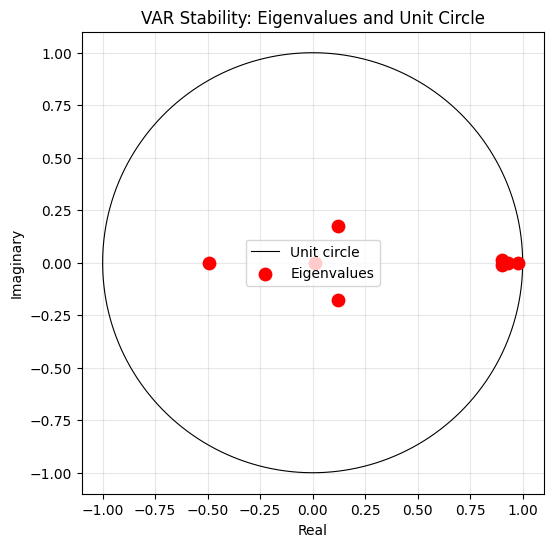


Maximum modulus: 0.9797


In [8]:
print(f"Is the VAR stable? {results.is_stable}")
print(f"\nEigenvalues of the companion matrix:")
for i, root in enumerate(results.roots):
    print(f"  lambda_{i+1} = {root:.4f}  (modulus = {abs(root):.4f})")

fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), "k-", linewidth=0.8, label="Unit circle")
roots = results.roots
ax.scatter(roots.real, roots.imag, color="red", s=80, zorder=5, label="Eigenvalues")
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.set_title("VAR Stability: Eigenvalues and Unit Circle")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"\nMaximum modulus: {max(abs(roots)):.4f}")

## 5. Model diagnostics

In [9]:
whiteness = results.test_whiteness(nlags=10)
print(f"Portmanteau test statistic: {whiteness['statistic']:.4f}")
print(f"p-value: {whiteness['pvalue']:.4f}")
print(f"Degrees of freedom: {whiteness['df']}")

if whiteness['pvalue'] > 0.05:
    print("=> Cannot reject H0: residuals are white noise (good).")
else:
    print("=> Reject H0: residuals are NOT white noise (consider more lags).")

Portmanteau test statistic: 843.3052
p-value: 0.0000
Degrees of freedom: 128
=> Reject H0: residuals are NOT white noise (consider more lags).


## 6. Forecasting

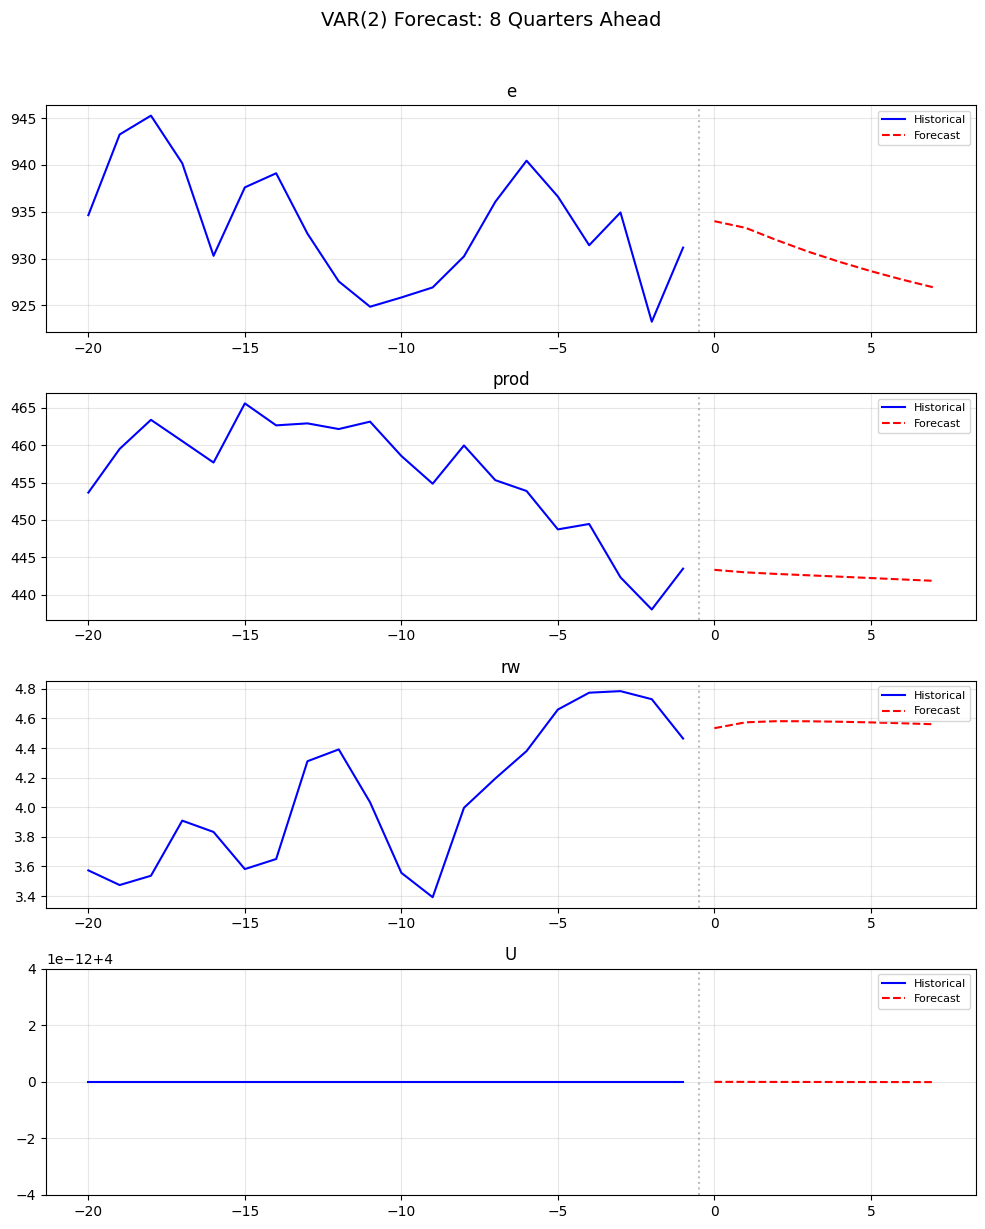

In [10]:
fig = results.plot_forecast(steps=8, alpha=0.05)
plt.suptitle("VAR(2) Forecast: 8 Quarters Ahead", fontsize=14, y=1.02)
plt.show()

In [11]:
print("Model fit statistics:")
print(f"  AIC:  {results.aic:.4f}")
print(f"  BIC:  {results.bic:.4f}")
print(f"  HQIC: {results.hqic:.4f}")
print(f"  FPE:  {results.fpe:.6f}")
print(f"  Observations (effective): {results.nobs}")
print(f"  Number of equations: {results.neqs}")
print(f"  Lag order: {results.k_ar}")

Model fit statistics:
  AIC:  -62.9240
  BIC:  -61.9848
  HQIC: -62.5470
  FPE:  0.000000
  Observations (effective): 82
  Number of equations: 4
  Lag order: 2


---

## Exercise 1: VAR on US Macro data (SOLUTION)

Use the `us_macro_quarterly.csv` dataset (GDP growth, inflation, fed funds rate, unemployment) to:

1. Load the data and visualize the series
2. Perform lag order selection up to 12 lags
3. Fit a VAR with the BIC-selected order
4. Check model stability
5. Interpret the inflation equation coefficients
6. **Save coefficients and information criteria to outputs/**

In [12]:
# Step 1: Load and visualize US Macro data
us_path = os.path.join("..", "data", "us_macro_quarterly.csv")
us_df = pd.read_csv(us_path)
us_names = ["gdp", "inflation", "fed_funds", "unemployment"]

print(f"Shape: {us_df.shape}")
print(f"Period: {us_df['date'].iloc[0]} to {us_df['date'].iloc[-1]}")
print(f"\nDescriptive statistics:")
print(us_df[us_names].describe().round(4))

Shape: (200, 5)
Period: 1975-01-01 to 2024-10-01

Descriptive statistics:
            gdp  inflation  fed_funds  unemployment
count  200.0000   200.0000   200.0000      200.0000
mean     3.2887     3.5060     6.0663        9.5263
std      0.7337     0.5926     0.8009        0.7042
min      1.4368     2.0996     4.2708        7.8187
25%      2.7721     3.1003     5.4672        9.0421
50%      3.2799     3.4474     6.0561        9.4308
75%      3.8317     3.8757     6.6588       10.0066
max      5.4662     5.3591     7.9500       11.2623


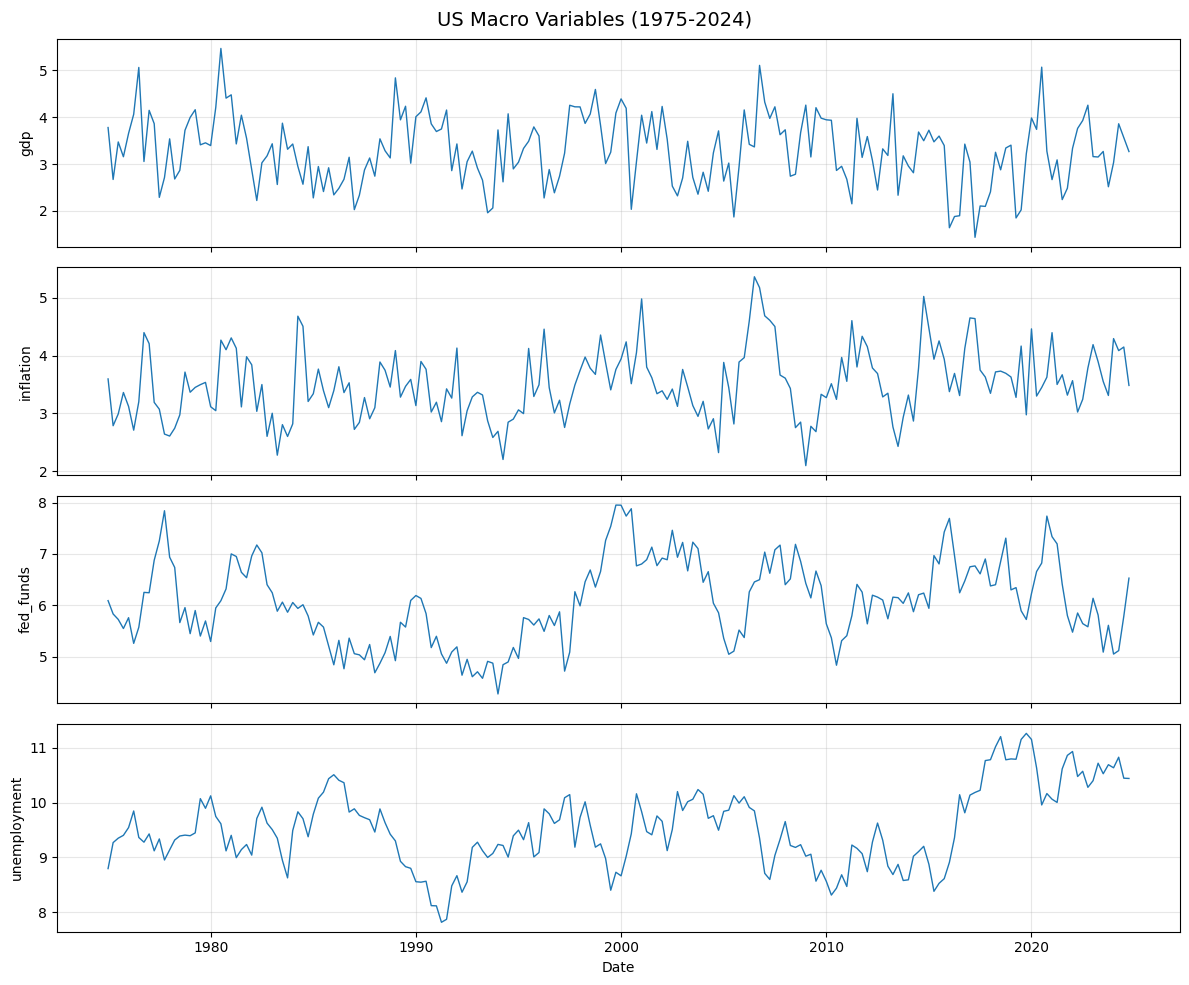

In [13]:
fig = plot_multivariate_series(us_df, date_col="date", title="US Macro Variables (1975-2024)")
plt.show()

In [14]:
# Step 2: Lag order selection
us_endog = us_df[us_names].values

us_lag = select_lag_order(us_endog, maxlags=12, trend="c")
print(us_lag.summary())

print("\nSelected lag orders:")
for crit, order in us_lag.selected_orders.items():
    print(f"  {crit}: p = {order}")

VAR Lag Order Selection
 Lag           AIC           BIC          HQIC             FPE
------------------------------------------------------------------------
   0      -3.0432      -3.0432      -3.0432   4.962555e-02 
   1      -6.5994*     -6.3346*     -6.4922*  1.417069e-03*
   2      -6.5651      -6.0337      -6.3500   1.467103e-03 
   3      -6.4848      -5.6848      -6.1610   1.590926e-03 
   4      -6.3476      -5.2772      -5.9142   1.827117e-03 
   5      -6.3039      -4.9611      -5.7602   1.912217e-03 
   6      -6.2274      -4.6103      -5.5726   2.069659e-03 
   7      -6.1639      -4.2706      -5.3972   2.213190e-03 
   8      -6.0978      -3.9261      -5.2182   2.376059e-03 
   9      -5.9908      -3.5388      -4.9976   2.660938e-03 
  10      -5.9370      -3.2027      -4.8294   2.830447e-03 
  11      -5.8889      -2.8702      -4.6660   2.999414e-03 
  12      -5.9066      -2.6013      -4.5674   2.983007e-03 
------------------------------------------------------------

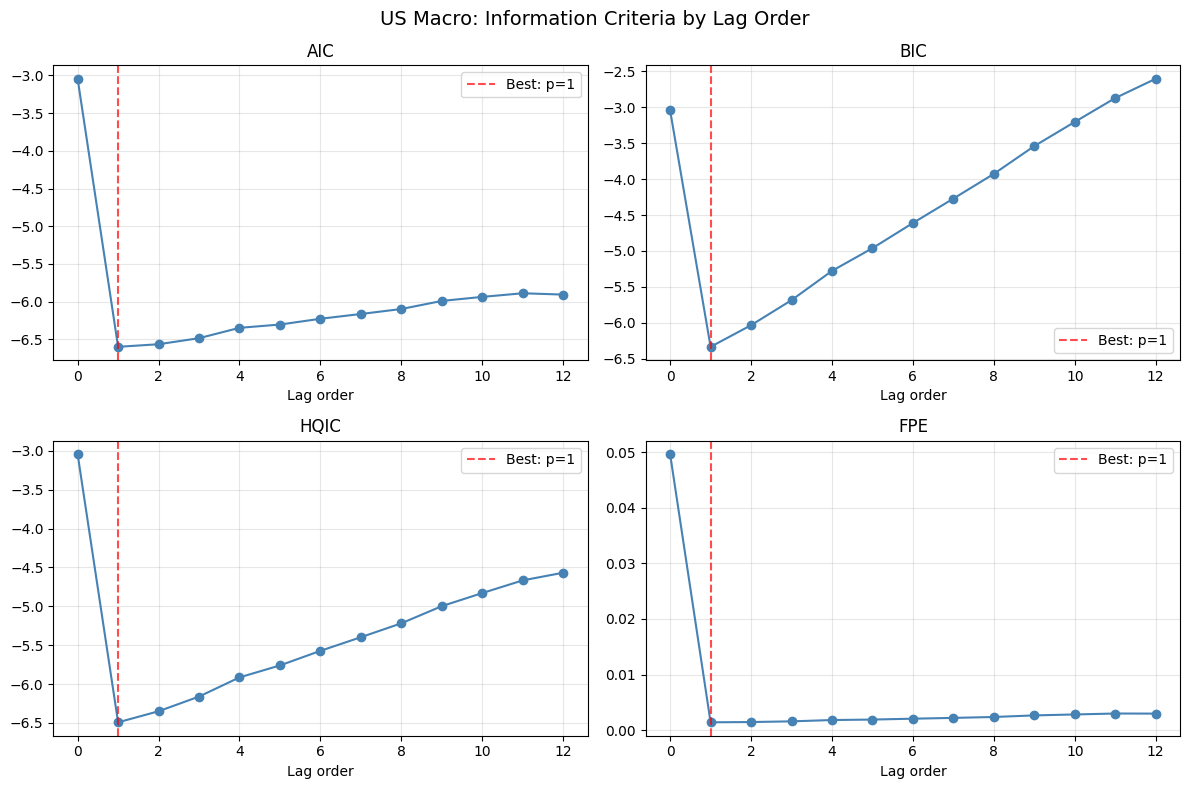

In [15]:
# Plot IC across lags for US data
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("US Macro: Information Criteria by Lag Order", fontsize=14)

us_criteria = {"AIC": us_lag.aic, "BIC": us_lag.bic,
               "HQIC": us_lag.hqic, "FPE": us_lag.fpe}

for ax, (name, vals) in zip(axes.flat, us_criteria.items()):
    lags = sorted(vals.keys())
    values = [vals[l] for l in lags]
    ax.plot(lags, values, "o-", color="steelblue")
    best = min(vals, key=vals.get)
    ax.axvline(best, color="red", linestyle="--", alpha=0.7, label=f"Best: p={best}")
    ax.set_title(name)
    ax.set_xlabel("Lag order")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Step 3: Fit VAR with BIC-selected order
p_bic = us_lag.selected_orders["bic"]
print(f"BIC selects p = {p_bic}")

us_model = VAR(lags=p_bic, trend="c")
us_results = us_model.fit(us_endog, names=us_names)

try:
    print(us_results.summary())
except np.linalg.LinAlgError:
    print(f"US VAR({p_bic}) estimated successfully.")
    print(f"Equations: {us_results.neqs}, Obs: {us_results.nobs}")
    print(f"AIC: {us_results.aic:.4f}, BIC: {us_results.bic:.4f}")
    print(f"Stable: {us_results.is_stable}")

BIC selects p = 1
  VAR(1) Estimation Results
  No. of equations:   4
  No. of lags:        1
  No. of obs (total): 200
  No. of obs (used):  199
  Trend:              c
  Stable:             True
  AIC:                -6.5994
  BIC:                -6.3346
  HQIC:               -6.4922
  FPE:                1.417069e-03

------------------------------------------------------------------------------
  Equation: gdp
------------------------------------------------------------------------------
  Variable                     Coef      Std.Err     t-stat    p-value
  --------------------------------------------------------------------------
  L1.gdp                   0.436804     0.069282     6.3047     0.0000
  L1.inflation            -0.015635     0.085768    -0.1823     0.8555
  L1.fed_funds            -0.030757     0.061248    -0.5022     0.6161
  L1.unemployment          0.024103     0.071878     0.3353     0.7377
  const                    1.861492     0.837438     2.2228     0.0274


Is the US VAR stable? True
Max eigenvalue modulus: 0.9109

Eigenvalues of the companion matrix:
  lambda_1 = 0.9109  (modulus = 0.9109)
  lambda_2 = 0.7510  (modulus = 0.7510)
  lambda_3 = 0.5140  (modulus = 0.5140)
  lambda_4 = 0.4597  (modulus = 0.4597)


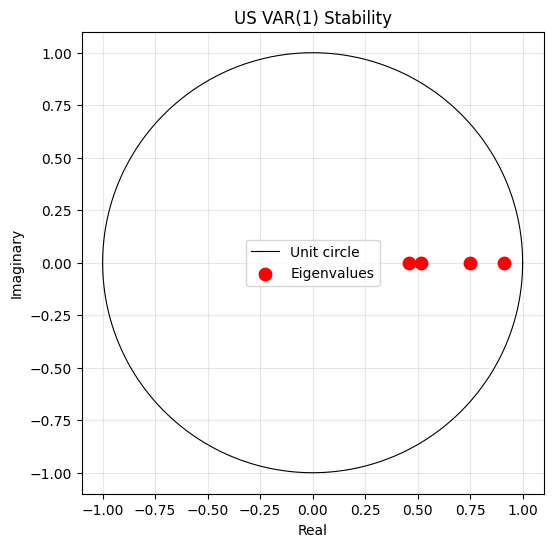

In [17]:
# Step 4: Stability check
print(f"Is the US VAR stable? {us_results.is_stable}")
print(f"Max eigenvalue modulus: {max(abs(us_results.roots)):.4f}")

print(f"\nEigenvalues of the companion matrix:")
for i, root in enumerate(us_results.roots):
    print(f"  lambda_{i+1} = {root:.4f}  (modulus = {abs(root):.4f})")

# Unit circle plot
fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), "k-", linewidth=0.8, label="Unit circle")
us_roots = us_results.roots
ax.scatter(us_roots.real, us_roots.imag, color="red", s=80, zorder=5, label="Eigenvalues")
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.set_title(f"US VAR({p_bic}) Stability")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [18]:
# Step 5: Interpret inflation equation coefficients
print("=" * 60)
print("INFLATION EQUATION COEFFICIENTS")
print("=" * 60)

infl_idx = us_names.index("inflation")

for lag in range(us_results.k_ar):
    print(f"\nLag {lag + 1}:")
    coef_row = us_results.coefs[lag][infl_idx]
    for j, name in enumerate(us_names):
        coef = coef_row[j]
        significance = "***" if abs(coef) > 0.1 else ""
        print(f"  {name:>15s}: {coef:>8.4f} {significance}")

print(f"\nIntercept for inflation: {us_results.intercept[infl_idx]:.4f}")

print("\n--- Economic Interpretation ---")
print("The inflation equation shows:")
print("- Inflation persistence: own lags capture the inertia of inflation.")
print("- Phillips curve: unemployment lags may negatively affect inflation.")
print("- Monetary transmission: fed funds lags capture policy effects on inflation.")
print("- Output-inflation link: GDP growth lags may push inflation up (demand pull).")

INFLATION EQUATION COEFFICIENTS

Lag 1:
              gdp:   0.0921 
        inflation:   0.5013 ***
        fed_funds:   0.0139 
     unemployment:   0.0666 

Intercept for inflation: 0.7264

--- Economic Interpretation ---
The inflation equation shows:
- Inflation persistence: own lags capture the inertia of inflation.
- Phillips curve: unemployment lags may negatively affect inflation.
- Monetary transmission: fed funds lags capture policy effects on inflation.
- Output-inflation link: GDP growth lags may push inflation up (demand pull).


In [19]:
# Model diagnostics for US data
us_whiteness = us_results.test_whiteness(nlags=10)
print(f"Portmanteau test statistic: {us_whiteness['statistic']:.4f}")
print(f"p-value: {us_whiteness['pvalue']:.4f}")

if us_whiteness['pvalue'] > 0.05:
    print("=> Cannot reject H0: residuals are white noise (good).")
else:
    print("=> Reject H0: residuals are NOT white noise (consider more lags).")

Portmanteau test statistic: 138.6088
p-value: 0.6111
=> Cannot reject H0: residuals are white noise (good).


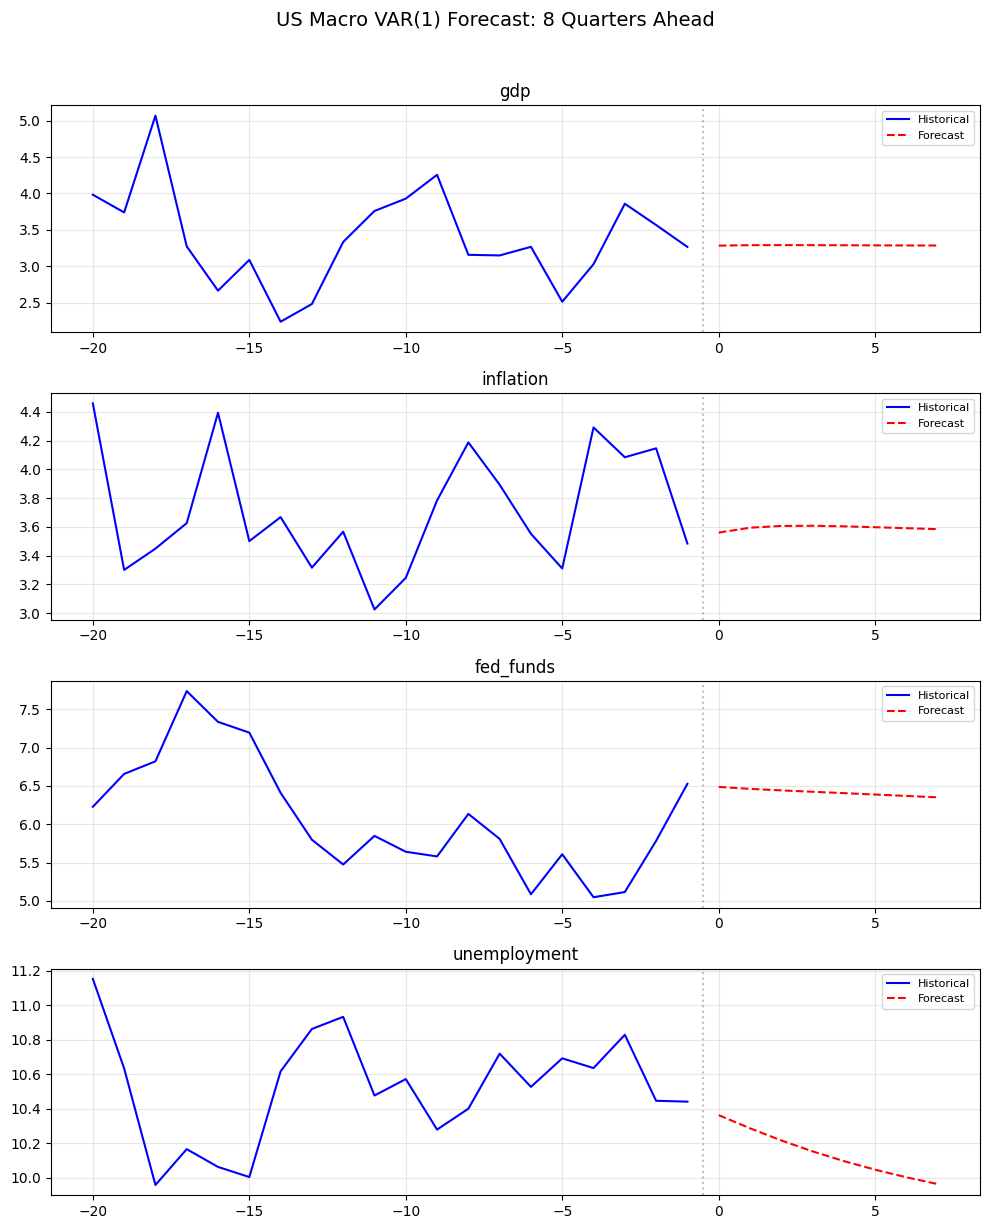

In [20]:
# Forecast US macro 8 quarters ahead
fig = us_results.plot_forecast(steps=8, alpha=0.05)
plt.suptitle(f"US Macro VAR({p_bic}) Forecast: 8 Quarters Ahead", fontsize=14, y=1.02)
plt.show()

In [21]:
# Step 6: Save coefficients to outputs/var_coefficients.json
outputs_dir = os.path.join("..", "outputs")
os.makedirs(outputs_dir, exist_ok=True)

var_coefficients = {
    "model": f"VAR({p_bic})",
    "dataset": "us_macro_quarterly.csv",
    "variables": us_names,
    "lag_order": int(p_bic),
    "trend": "c",
    "nobs": int(us_results.nobs),
    "neqs": int(us_results.neqs),
    "is_stable": bool(us_results.is_stable),
    "max_eigenvalue_modulus": float(max(abs(us_results.roots))),
    "intercept": us_results.intercept.tolist(),
    "coefficients": {},
    "residual_covariance": us_results.sigma_u.tolist()
}

for lag in range(us_results.k_ar):
    lag_key = f"A_{lag + 1}"
    coef_df = pd.DataFrame(us_results.coefs[lag], index=us_names, columns=us_names)
    var_coefficients["coefficients"][lag_key] = coef_df.to_dict()

coef_path = os.path.join(outputs_dir, "var_coefficients.json")
with open(coef_path, "w") as f:
    json.dump(var_coefficients, f, indent=2)

print(f"Coefficients saved to {coef_path}")
print(f"\nSaved content preview:")
print(f"  Model: {var_coefficients['model']}")
print(f"  Variables: {var_coefficients['variables']}")
print(f"  Stable: {var_coefficients['is_stable']}")
print(f"  Max eigenvalue modulus: {var_coefficients['max_eigenvalue_modulus']:.4f}")

Coefficients saved to ../outputs/var_coefficients.json

Saved content preview:
  Model: VAR(1)
  Variables: ['gdp', 'inflation', 'fed_funds', 'unemployment']
  Stable: True
  Max eigenvalue modulus: 0.9109


In [22]:
# Save information criteria to outputs/var_ic.csv
ic_data = []
for lag in sorted(us_lag.aic.keys()):
    ic_data.append({
        "lag": lag,
        "aic": us_lag.aic[lag],
        "bic": us_lag.bic[lag],
        "hqic": us_lag.hqic[lag],
        "fpe": us_lag.fpe[lag]
    })

ic_df = pd.DataFrame(ic_data)
ic_path = os.path.join(outputs_dir, "var_ic.csv")
ic_df.to_csv(ic_path, index=False)

print(f"Information criteria saved to {ic_path}")
print()
print(ic_df.to_string(index=False))

print(f"\nBest orders:")
print(f"  AIC  -> p = {us_lag.selected_orders['aic']}")
print(f"  BIC  -> p = {us_lag.selected_orders['bic']}")
print(f"  HQIC -> p = {us_lag.selected_orders['hqic']}")
print(f"  FPE  -> p = {us_lag.selected_orders['fpe']}")

Information criteria saved to ../outputs/var_ic.csv

 lag       aic       bic      hqic      fpe
   0 -3.043250 -3.043250 -3.043250 0.049626
   1 -6.599408 -6.334619 -6.492241 0.001417
   2 -6.565120 -6.033683 -6.350012 0.001467
   3 -6.484817 -5.684848 -6.160983 0.001591
   4 -6.347580 -5.277176 -5.914229 0.001827
   5 -6.303872 -4.961103 -5.760201 0.001912
   6 -6.227373 -4.610288 -5.572570 0.002070
   7 -6.163943 -4.270568 -5.397187 0.002213
   8 -6.097764 -3.926100 -5.218224 0.002376
   9 -5.990795 -3.538820 -4.997631 0.002661
  10 -5.936996 -3.202660 -4.829356 0.002830
  11 -5.888936 -2.870166 -4.665959 0.002999
  12 -5.906615 -2.601313 -4.567431 0.002983

Best orders:
  AIC  -> p = 1
  BIC  -> p = 1
  HQIC -> p = 1
  FPE  -> p = 1


---

## Exercise 2: Model comparison across lag orders (SOLUTION)

Fit VAR(1), VAR(2), VAR(3), and VAR(4) on the Canadian data and compare:
- AIC of each model
- Stability of each model
- Whiteness test results

In [23]:
# Comprehensive model comparison
print("Model Comparison: VAR(1) through VAR(4)")
print("=" * 80)
print(f"{'p':>3s}  {'AIC':>10s}  {'BIC':>10s}  {'HQIC':>10s}  {'FPE':>12s}  "
      f"{'Stable':>8s}  {'Whiteness p':>12s}  {'Conclusion':>15s}")
print("-" * 80)

comparison_results = []
for p in [1, 2, 3, 4]:
    m = VAR(lags=p, trend="c")
    r = m.fit(endog, names=var_names)
    w = r.test_whiteness(nlags=10)
    
    white_ok = "OK" if w['pvalue'] > 0.05 else "FAIL"
    conclusion = ""
    if r.is_stable and w['pvalue'] > 0.05:
        conclusion = "ADEQUATE"
    elif not r.is_stable:
        conclusion = "UNSTABLE"
    else:
        conclusion = "AUTOCORREL."
    
    print(f"{p:>3d}  {r.aic:>10.4f}  {r.bic:>10.4f}  {r.hqic:>10.4f}  {r.fpe:>12.6f}  "
          f"{str(r.is_stable):>8s}  {w['pvalue']:>12.4f}  {conclusion:>15s}")
    
    comparison_results.append({
        "lag": p, "aic": r.aic, "bic": r.bic, "hqic": r.hqic,
        "fpe": r.fpe, "stable": r.is_stable,
        "whiteness_pvalue": w['pvalue'], "max_modulus": float(max(abs(r.roots)))
    })

Model Comparison: VAR(1) through VAR(4)
  p         AIC         BIC        HQIC           FPE    Stable   Whiteness p       Conclusion
--------------------------------------------------------------------------------
  1    -61.0146    -60.5483    -60.8272      0.000000      True        0.0000      AUTOCORREL.
  2    -62.9240    -61.9848    -62.5470      0.000000      True        0.0000      AUTOCORREL.
  3    -64.2942    -62.8752    -63.7249      0.000000      True        0.0000      AUTOCORREL.
  4    -64.2358    -62.3302    -63.4718      0.000000      True        0.0000      AUTOCORREL.


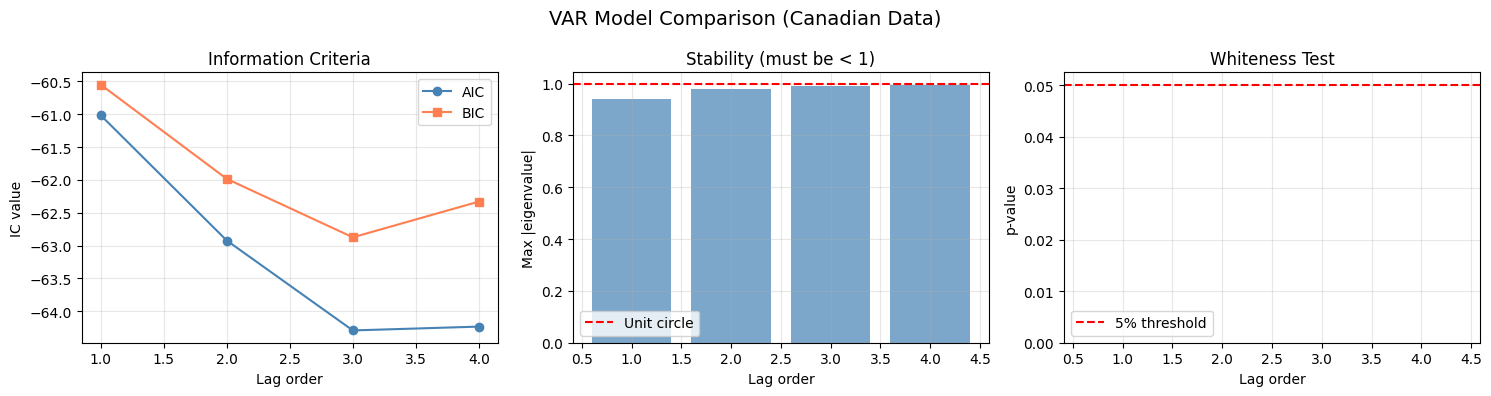

In [24]:
# Visual comparison
comp_df = pd.DataFrame(comparison_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# AIC/BIC comparison
ax = axes[0]
ax.plot(comp_df["lag"], comp_df["aic"], "o-", label="AIC", color="steelblue")
ax.plot(comp_df["lag"], comp_df["bic"], "s-", label="BIC", color="coral")
ax.set_xlabel("Lag order")
ax.set_ylabel("IC value")
ax.set_title("Information Criteria")
ax.legend()
ax.grid(True, alpha=0.3)

# Max eigenvalue modulus
ax = axes[1]
ax.bar(comp_df["lag"], comp_df["max_modulus"], color="steelblue", alpha=0.7)
ax.axhline(1.0, color="red", linestyle="--", label="Unit circle")
ax.set_xlabel("Lag order")
ax.set_ylabel("Max |eigenvalue|")
ax.set_title("Stability (must be < 1)")
ax.legend()
ax.grid(True, alpha=0.3)

# Whiteness p-values
ax = axes[2]
colors = ["green" if p > 0.05 else "red" for p in comp_df["whiteness_pvalue"]]
ax.bar(comp_df["lag"], comp_df["whiteness_pvalue"], color=colors, alpha=0.7)
ax.axhline(0.05, color="red", linestyle="--", label="5% threshold")
ax.set_xlabel("Lag order")
ax.set_ylabel("p-value")
ax.set_title("Whiteness Test")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("VAR Model Comparison (Canadian Data)", fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# Final recommendation
print("=" * 60)
print("MODEL SELECTION RECOMMENDATION")
print("=" * 60)

best_aic_lag = comp_df.loc[comp_df["aic"].idxmin(), "lag"]
best_bic_lag = comp_df.loc[comp_df["bic"].idxmin(), "lag"]

print(f"\n  AIC selects: VAR({int(best_aic_lag)})")
print(f"  BIC selects: VAR({int(best_bic_lag)})")

# Find adequate models
adequate = comp_df[(comp_df["stable"] == True) & (comp_df["whiteness_pvalue"] > 0.05)]
if len(adequate) > 0:
    rec = int(adequate.loc[adequate["bic"].idxmin(), "lag"])
    print(f"\n  Recommended: VAR({rec}) (lowest BIC among adequate models)")
    print(f"  - Stable: Yes")
    print(f"  - White noise residuals: Yes")
    print(f"  - BIC: {adequate.loc[adequate['bic'].idxmin(), 'bic']:.4f}")
else:
    print("\n  No model passes both stability and whiteness tests.")
    print("  Consider increasing the maximum lag order.")

MODEL SELECTION RECOMMENDATION

  AIC selects: VAR(3)
  BIC selects: VAR(3)

  No model passes both stability and whiteness tests.
  Consider increasing the maximum lag order.


---

## Summary

In this solution notebook we:

1. Fitted a VAR model on the Canadian macro data with full diagnostics
2. **Exercise 1**: Applied VAR to US macro data with lag selection, stability checks, and coefficient interpretation
3. **Exercise 2**: Compared VAR(1)-VAR(4) on multiple criteria (IC, stability, whiteness)
4. Saved all outputs:
   - `outputs/var_coefficients.json` - US VAR coefficient matrices and metadata
   - `outputs/var_ic.csv` - Information criteria across lag orders